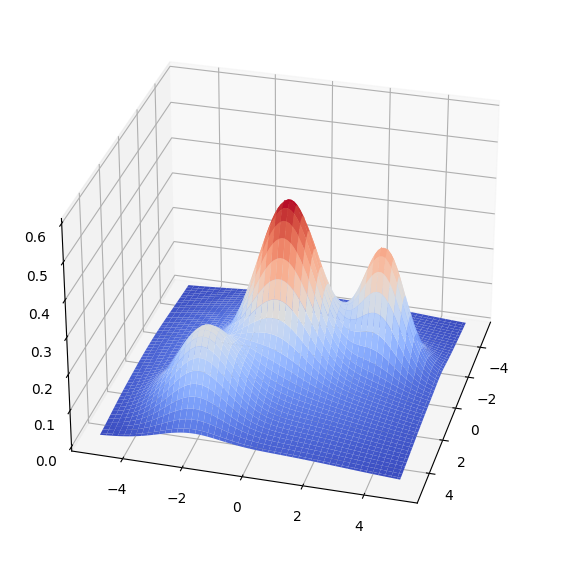

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# Define Gaussian function
def f(x: float, y: float) -> float:
    return (
        0.4 * np.exp(-0.5 * (x**2 + y**2)) +
        0.3 * np.exp(-0.5 * ((x+1)**2 + (y-3)**2)*2) +
        0.2 * np.exp(-0.5 * ((x-3)**2 + (y+2)**2)) +
        0.1 * np.exp(-0.5 * (x**2 + y**2)/10)
    )

# Generate grid
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
x, y = np.meshgrid(x, y)
z = f(x, y)

# Plot
fig = plt.figure(figsize=(7, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_zlim(0, 0.6)
ax.view_init(30, 15)
ax.plot_surface(x, y, z, cmap='coolwarm')
plt.show()


In [60]:
import random

def g(x, y):
    p = f(x, y)
    r = np.random.random(1)
    return 1 if r <p else 0

In [95]:
from hyperopt import hp
import numpy as np

def objective(params):
    x, y = params['x'], params['y']
    samples = [g(x, y) for _ in range(30)]
    mean = np.mean(samples)
    variance = np.var(samples)
    return {
        'status': 'ok',
        'loss': -mean,
        'variance': variance,
    }


In [96]:
from hyperopt import fmin, tpe, Trials

space = {
    'x': hp.uniform('x', -5, 5),
    'y': hp.uniform('y', -5, 5)
}

trials = Trials()
best = fmin(objective, space, algo=tpe.suggest, max_evals=1000, trials=trials)


100%|█████████████████████████████████████████████████████████| 1000/1000 [00:07<00:00, 133.03trial/s, best loss: -0.7]


In [97]:
best

{'x': 0.23051219856147998, 'y': 0.12944348873927447}

In [98]:
import pandas as pd
import datetime

def trials_to_df(trials):
    rows = []
    for trial in trials:
        row = {
            'tid': trial['tid'],
            'loss': -trial['result']['loss'],
            'variance': trial['result']['variance'],
            'x': trial['misc']['vals']['x'][0],
            'y': trial['misc']['vals']['y'][0],
            'book_time': trial['book_time'],
            'refresh_time': trial['refresh_time']
        }
        rows.append(row)
    return pd.DataFrame(rows)

df = trials_to_df(trials)
df

,tid,loss,variance,x,y,book_time,refresh_time
0,0,0.100000,0.090000,-3.768644,0.163273,2023-09-28 15:23:04.971,2023-09-28 15:23:04.972
1,1,0.133333,0.115556,3.965949,-1.008960,2023-09-28 15:23:04.973,2023-09-28 15:23:04.973
2,2,0.233333,0.178889,2.716864,-1.334933,2023-09-28 15:23:04.974,2023-09-28 15:23:04.975
3,3,0.000000,0.000000,2.358303,4.892684,2023-09-28 15:23:04.976,2023-09-28 15:23:04.976
4,4,0.133333,0.115556,-3.311765,0.967634,2023-09-28 15:23:04.977,2023-09-28 15:23:04.978
...,...,...,...,...,...,...,...
995,995,0.266667,0.195556,-0.108484,-0.898719,2023-09-28 15:23:12.445,2023-09-28 15:23:12.445
996,996,0.133333,0.115556,-0.444897,-1.802375,2023-09-28 15:23:12.455,2023-09-28 15:23:12.455
997,997,0.466667,0.248889,0.516460,0.351599,2023-09-28 15:23:12.465,2023-09-28 15:23:12.465
998,998,0.066667,0.062222,-2.034378,-0.666408,2023-09-28 15:23:12.475,2023-09-28 15:23:12.475


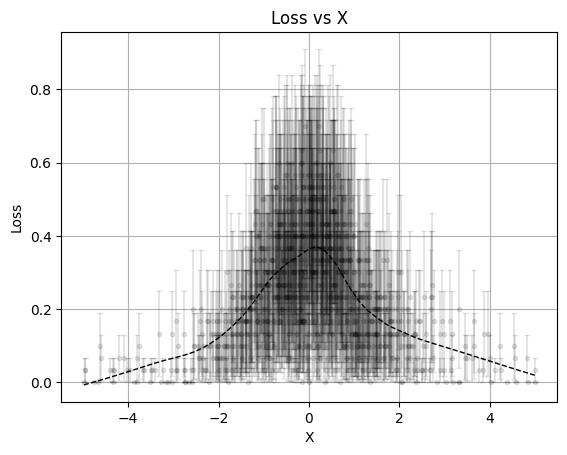

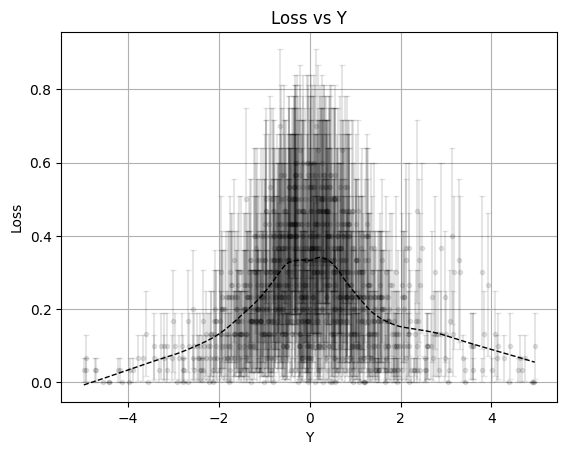

In [99]:
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

def univariate_plot(df, x_column, x_label, bandwidth=0.3):
    smooth = lowess(df['loss'], df[x_column], frac=bandwidth)
    
    fig, ax = plt.subplots()
    
    for idx, row in df.iterrows():
        ax.errorbar(row[x_column], row['loss'], yerr=row['variance'], fmt='.', capsize=2, alpha=0.1, color='black')
        
    ax.plot(smooth[:, 0], smooth[:, 1], 'black', linestyle="--", linewidth=1.0)
    
    ax.set_xlabel(x_label)
    ax.set_ylabel('Loss')
    ax.set_title(f'Loss vs {x_label}')
    ax.grid(True)

# For variable 'x'
univariate_plot(df, 'x', 'X', bandwidth=0.3)

# For variable 'y'
univariate_plot(df, 'y', 'Y', bandwidth=0.3)


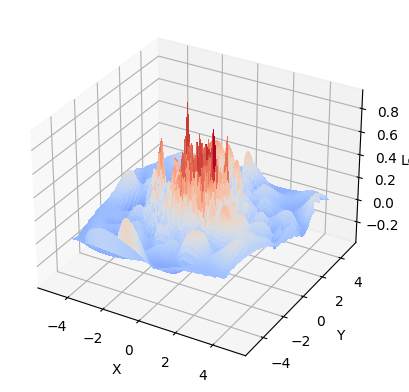

In [100]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import numpy as np
from scipy.interpolate import griddata

# Create a grid to interpolate onto
xi = np.linspace(df['x'].min(), df['x'].max(), num=100)
yi = np.linspace(df['y'].min(), df['y'].max(), num=100)
xi, yi = np.meshgrid(xi, yi)

# Interpolate the unstructured data onto the grid
zi = griddata((df['x'], df['y']), df['loss'], (xi, yi), method='cubic')

# Create the figure and axes
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Create the surface plot
ax.plot_surface(xi, yi, zi, rstride=1, cstride=1, cmap=cm.coolwarm, linewidth=0, antialiased=False)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Loss')
plt.show()


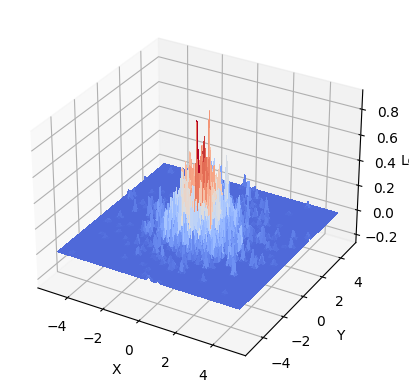

In [101]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Data preparation
X = df[['x', 'y']].values
y = df['loss'].values

# Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

gp.fit(X, y)

# Create grid
x_pred = np.linspace(df['x'].min(), df['x'].max(), 100)
y_pred = np.linspace(df['y'].min(), df['y'].max(), 100)
xx, yy = np.meshgrid(x_pred, y_pred)

# Predict
Z_pred = gp.predict(np.c_[xx.ravel(), yy.ravel()])
zz = Z_pred.reshape(xx.shape)

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx, yy, zz, rstride=1, cstride=1, cmap=cm.coolwarm, linewidth=0, antialiased=False)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Loss')
plt.show()


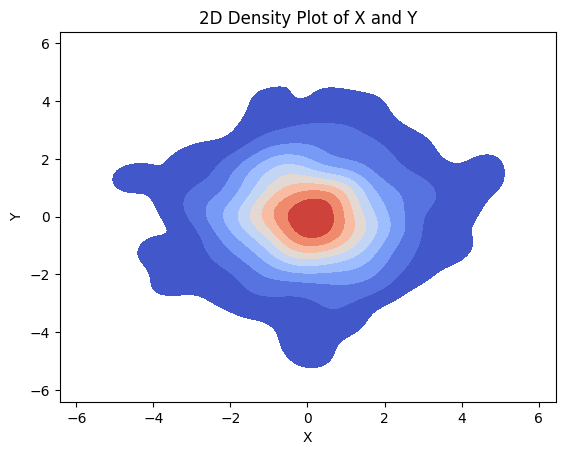

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the density plot
sns.kdeplot(
    data=df, x='x', y='y', cmap="coolwarm", fill=True
)

# Add labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Density Plot of X and Y')

# Show the plot
plt.show()


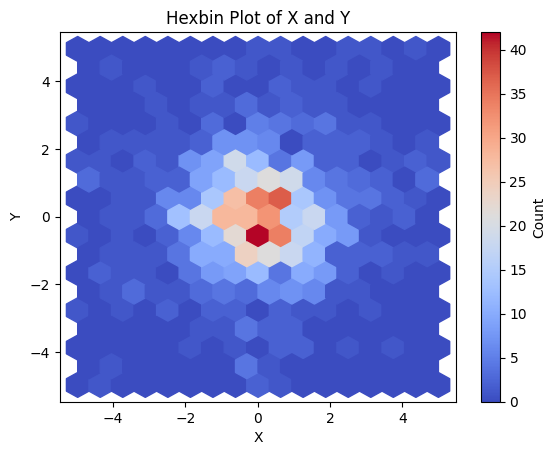

In [105]:
import matplotlib.pyplot as plt

plt.hexbin(df['x'], df['y'], gridsize=16, cmap='coolwarm')
plt.colorbar(label='Count')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Hexbin Plot of X and Y')
plt.show()
